In [ ]:
import kagglehub

# Descarga la última versión del dataset
dataset_path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Ruta local donde se encuentran los archivos:", dataset_path)


Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Ruta local donde se encuentran los archivos: /kaggle/input/telco-customer-churn


In [ ]:
import pandas as pd
import os

# Construimos la ruta completa al archivo
csv_file = os.path.join(dataset_path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Cargar en pandas
df = pd.read_csv(csv_file)
print(df.head())


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [ ]:
import kagglehub

# Descarga la última versión del dataset
dataset_path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Ruta local donde se encuentran los archivos:", dataset_path)


=== PREPROCESAMIENTO PARA DECISION TREE ===
Valores nulos en TotalCharges: 11
gender: {'Female': np.int64(0), 'Male': np.int64(1)}
Partner: {'No': np.int64(0), 'Yes': np.int64(1)}
Dependents: {'No': np.int64(0), 'Yes': np.int64(1)}
PhoneService: {'No': np.int64(0), 'Yes': np.int64(1)}
MultipleLines: {'No': np.int64(0), 'No phone service': np.int64(1), 'Yes': np.int64(2)}
InternetService: {'DSL': np.int64(0), 'Fiber optic': np.int64(1), 'No': np.int64(2)}
OnlineSecurity: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
OnlineBackup: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
DeviceProtection: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
TechSupport: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
StreamingTV: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
StreamingMovies: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int6

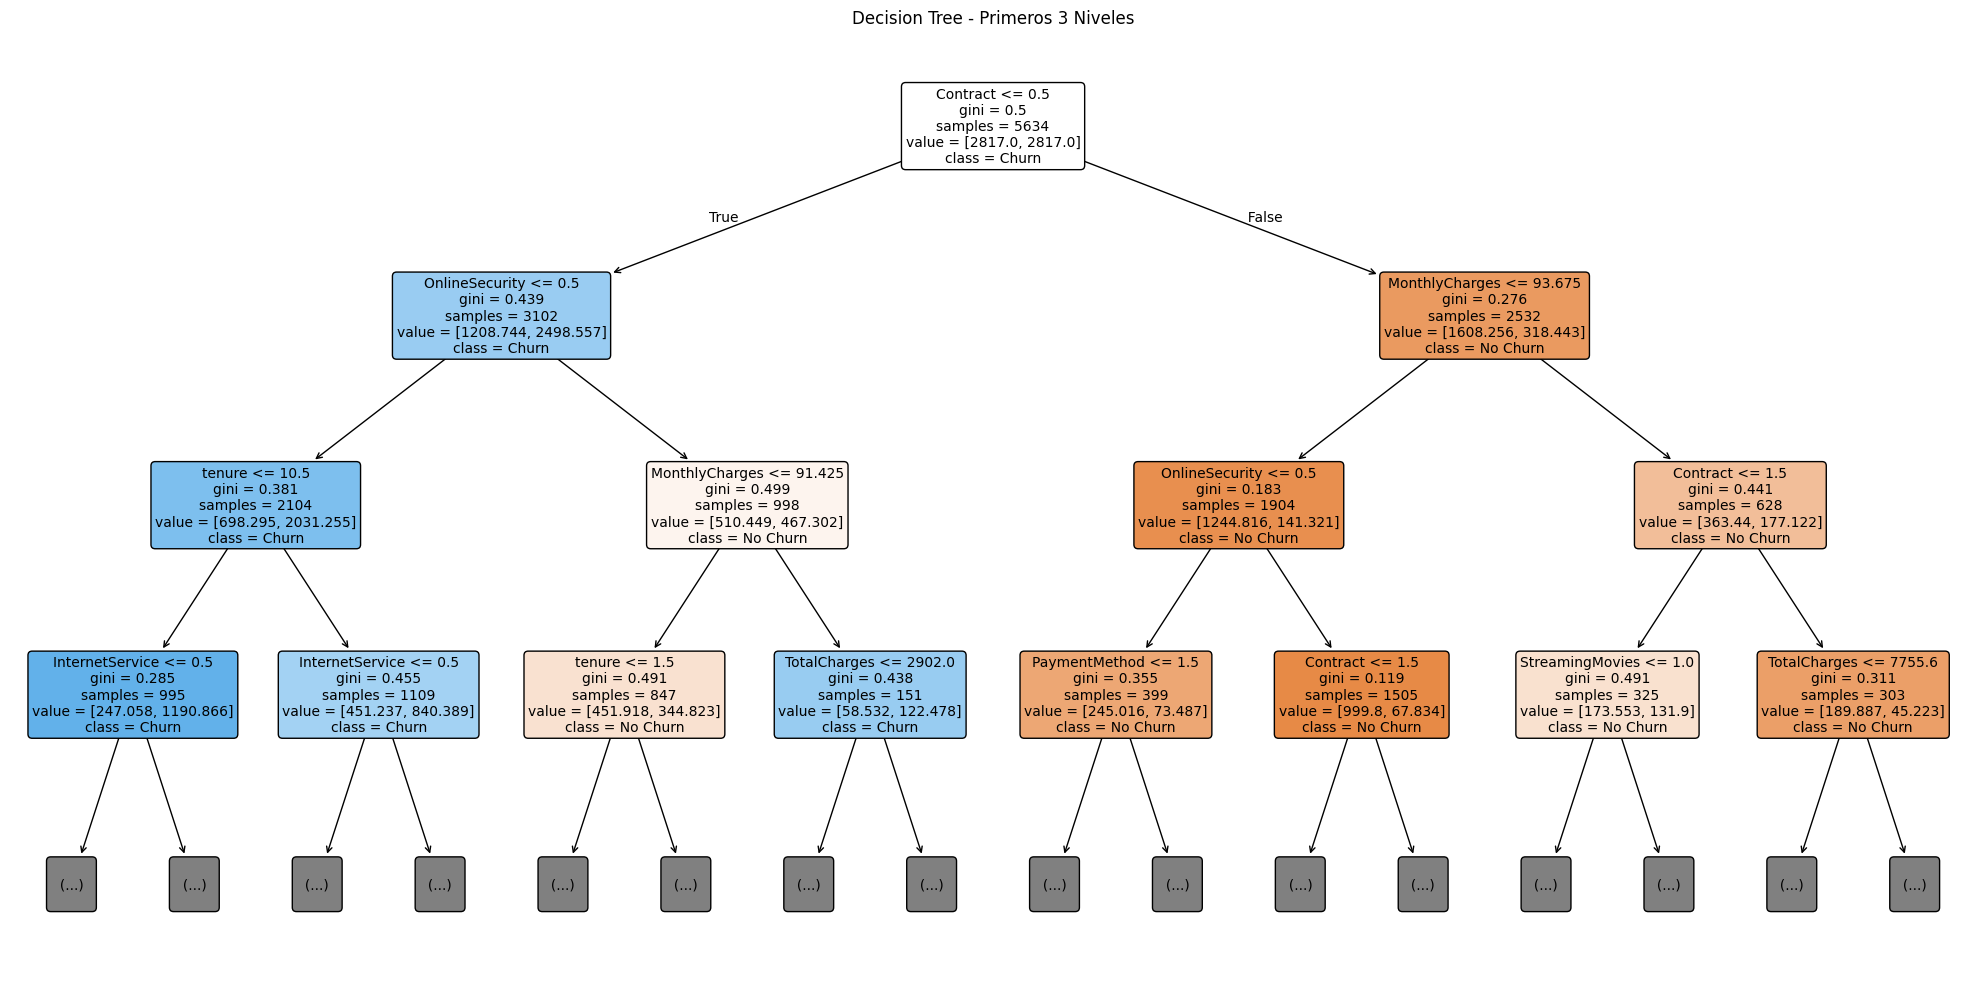


=== REGLAS DE NEGOCIO PRINCIPALES ===

Top 5 Reglas de Negocio (por cantidad de clientes):

Regla 11:
Condición:  Contract > 0.50 MonthlyCharges <= 93.67 OnlineSecurity > 0.50 Contract <= 1.50
Clientes afectados: 1
Probabilidad de churn: 11.07%
Predicción: No Churn

Regla 16:
Condición:  Contract > 0.50 MonthlyCharges > 93.67 Contract > 1.50 TotalCharges > 7755.60
Clientes afectados: 1
Probabilidad de churn: 0.00%
Predicción: No Churn

Regla 12:
Condición:  Contract > 0.50 MonthlyCharges <= 93.67 OnlineSecurity > 0.50 Contract > 1.50
Clientes afectados: 1
Probabilidad de churn: 3.23%
Predicción: No Churn

Regla 1:
Condición:  Contract <= 0.50 OnlineSecurity <= 0.50 tenure <= 10.50 InternetService <= 0.50
Clientes afectados: 0
Probabilidad de churn: 71.01%
Predicción: Churn

Regla 5:
Condición:  Contract <= 0.50 OnlineSecurity > 0.50 MonthlyCharges <= 91.42 tenure <= 1.50
Clientes afectados: 0
Probabilidad de churn: 63.23%
Predicción: Churn

=== ANÁLISIS DE SENSIBILIDAD ===
Importancia

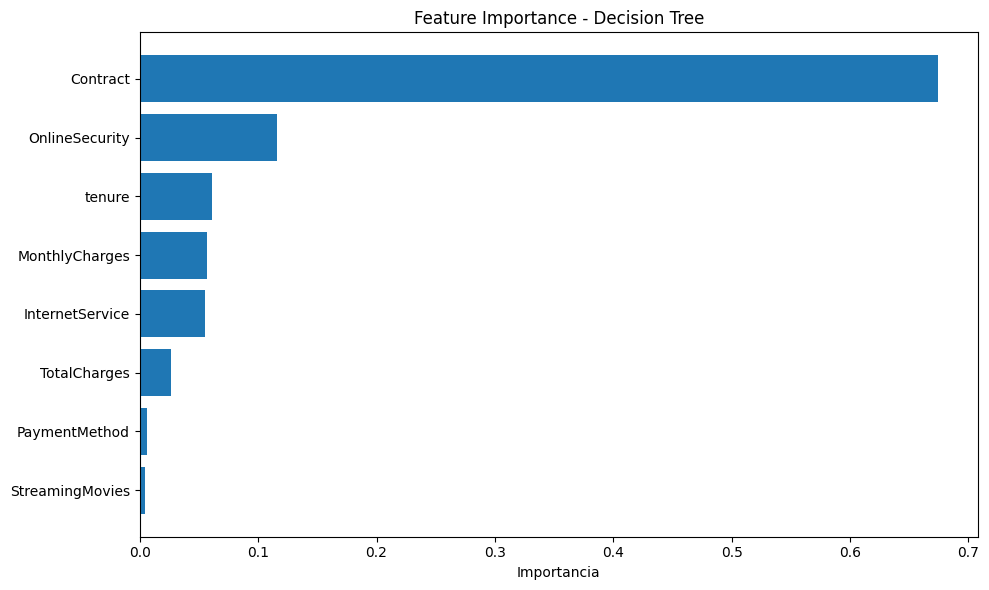


Variables más decisivas: ['Contract', 'OnlineSecurity', 'tenure']

=== INSIGHTS DE NEGOCIO ===
1. VARIABLES CLAVE IDENTIFICADAS:
   1. Contract (importancia: 0.674)
   2. OnlineSecurity (importancia: 0.116)
   3. tenure (importancia: 0.061)

2. REGLAS ACCIONABLES:
   Regla principal:  Contract > 0.50 MonthlyCharges <= 93.67 OnlineSecurity > 0.50 Contract <= 1.50
   - Afecta a 1 clientes
   - Probabilidad de churn: 11.1%

3. RECOMENDACIONES:
   - Enfocar campañas en clientes que cumplan las condiciones de alto riesgo
   - Monitorear variables contractuales y de tenure críticas
   - Diseñar intervenciones específicas basadas en las reglas identificadas

=== COMPARACIÓN CON MODELO SIMPLE ===
F1-Score modelo optimizado: 0.6176
F1-Score modelo simple: 0.5204
Mejora: 0.0973

=== ANÁLISIS COMPLETADO ===

Resumen ejecutivo:
model: Decision Tree
f1_score: 0.6176470588235294
top_features: ['Contract', 'OnlineSecurity', 'tenure']
best_params: {'class_weight': 'balanced', 'max_depth': 4, 'min_sam

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.inspection import permutation_importance
import graphviz
from sklearn.tree import export_graphviz

# 1. PREPROCESAMIENTO ESPECÍFICO PARA DECISION TREE
print("=== PREPROCESAMIENTO PARA DECISION TREE ===")

# Cargar datos (asumiendo que df ya existe)
# df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Convertir TotalCharges a numérico
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Verificar y manejar valores nulos
print(f"Valores nulos en TotalCharges: {df['TotalCharges'].isnull().sum()}")
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Eliminar customerID
df = df.drop('customerID', axis=1)

# Codificar variable objetivo
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Para Decision Tree, usamos LabelEncoder en lugar de OneHot para mejor interpretabilidad
categorical_columns = ['gender', 'Partner', 'Dependents', 'PhoneService',
                      'MultipleLines', 'InternetService', 'OnlineSecurity',
                      'OnlineBackup', 'DeviceProtection', 'TechSupport',
                      'StreamingTV', 'StreamingMovies', 'Contract',
                      'PaperlessBilling', 'PaymentMethod']

# Aplicar LabelEncoder
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# 2. PREPARAR DATOS
print("\n=== PREPARACIÓN DE DATOS ===")

X = df.drop('Churn', axis=1)
y = df['Churn']

# Split de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Proporción de churn en training: {y_train.mean():.3f}")

# 3. ENTRENAR DECISION TREE CON OPTIMIZACIÓN
print("\n=== ENTRENAMIENTO DECISION TREE ===")

# Búsqueda de hiperparámetros para evitar overfitting
param_grid = {
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_split': [20, 50, 100],
    'min_samples_leaf': [10, 20, 30],
    'class_weight': ['balanced', None]
}

dt_model = DecisionTreeClassifier(random_state=42)

# Grid Search para encontrar mejores parámetros
grid_search = GridSearchCV(
    dt_model, param_grid, cv=5, scoring='f1', n_jobs=-1
)
grid_search.fit(X_train, y_train)

# Mejor modelo
best_dt = grid_search.best_estimator_
print(f"Mejores parámetros: {grid_search.best_params_}")

# 4. EVALUACIÓN
print("\n=== EVALUACIÓN DEL MODELO ===")

y_pred = best_dt.predict(X_test)
y_pred_proba = best_dt.predict_proba(X_test)[:, 1]

print("Matriz de Confusión:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

f1 = f1_score(y_test, y_pred)
print(f"F1-Score: {f1:.4f}")

# 5. INTERPRETABILIDAD - ANÁLISIS DEL ÁRBOL
print("\n=== ANÁLISIS DE INTERPRETABILIDAD ===")

# 5.1 Feature Importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_dt.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Features más importantes:")
print(feature_importance.head(10))

# 5.2 Visualización del árbol
plt.figure(figsize=(20, 10))
plot_tree(best_dt,
          feature_names=X.columns,
          class_names=['No Churn', 'Churn'],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3)  # Mostrar solo primeros 3 niveles para legibilidad
plt.title('Decision Tree - Primeros 3 Niveles')
plt.tight_layout()
plt.show()

# 5.3 Reglas de negocio extraídas
print("\n=== REGLAS DE NEGOCIO PRINCIPALES ===")

# Analizar el árbol para extraer reglas
tree_rules = []

def extract_rules(tree, feature_names, class_names, node_index=0, rule=""):
    if tree.feature[node_index] != -2:  # Si no es hoja
        feature_name = feature_names[tree.feature[node_index]]
        threshold = tree.threshold[node_index]

        # Rama izquierda (<= threshold)
        left_rule = f"{rule} {feature_name} <= {threshold:.2f}"
        extract_rules(tree, feature_names, class_names,
                     tree.children_left[node_index], left_rule)

        # Rama derecha (> threshold)
        right_rule = f"{rule} {feature_name} > {threshold:.2f}"
        extract_rules(tree, feature_names, class_names,
                     tree.children_right[node_index], right_rule)
    else:
        # Es hoja - guardar regla
        class_prob = tree.value[node_index][0]
        total_samples = class_prob.sum()
        churn_prob = class_prob[1] / total_samples
        class_name = class_names[np.argmax(class_prob)]

        tree_rules.append({
            'rule': rule,
            'samples': int(total_samples),
            'churn_probability': churn_prob,
            'predicted_class': class_name
        })

# Extraer reglas
extract_rules(best_dt.tree_, X.columns, ['No Churn', 'Churn'])

# Mostrar reglas más importantes (con más samples)
tree_rules_df = pd.DataFrame(tree_rules)
tree_rules_df = tree_rules_df.sort_values('samples', ascending=False)

print("\nTop 5 Reglas de Negocio (por cantidad de clientes):")
for i, row in tree_rules_df.head(5).iterrows():
    print(f"\nRegla {i+1}:")
    print(f"Condición: {row['rule']}")
    print(f"Clientes afectados: {row['samples']}")
    print(f"Probabilidad de churn: {row['churn_probability']:.2%}")
    print(f"Predicción: {row['predicted_class']}")

# 6. ANÁLISIS DE SENSIBILIDAD POR VARIABLE
print("\n=== ANÁLISIS DE SENSIBILIDAD ===")

# Permutation Importance
perm_importance = permutation_importance(
    best_dt, X_test, y_test, n_repeats=10, random_state=42, scoring='f1'
)

perm_df = pd.DataFrame({
    'feature': X.columns,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

print("Importancia por Permutación:")
print(perm_df.head(8))

# 7. VISUALIZACIONES COMPLEMENTARIAS
print("\n=== VISUALIZACIONES ===")

# 7.1 Feature Importance gráfico
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(8)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importancia')
plt.title('Feature Importance - Decision Tree')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 7.2 Análisis de las variables top
top_3_features = feature_importance.head(3)['feature'].tolist()
print(f"\nVariables más decisivas: {top_3_features}")

# 8. INSIGHTS DE NEGOCIO
print("\n=== INSIGHTS DE NEGOCIO ===")

print("1. VARIABLES CLAVE IDENTIFICADAS:")
for i, feature in enumerate(top_3_features, 1):
    importance = feature_importance[feature_importance['feature'] == feature]['importance'].values[0]
    print(f"   {i}. {feature} (importancia: {importance:.3f})")

print("\n2. REGLAS ACCIONABLES:")
top_rule = tree_rules_df.iloc[0]
print(f"   Regla principal: {top_rule['rule']}")
print(f"   - Afecta a {top_rule['samples']} clientes")
print(f"   - Probabilidad de churn: {top_rule['churn_probability']:.1%}")

print("\n3. RECOMENDACIONES:")
print("   - Enfocar campañas en clientes que cumplan las condiciones de alto riesgo")
print("   - Monitorear variables contractuales y de tenure críticas")
print("   - Diseñar intervenciones específicas basadas en las reglas identificadas")

# 9. COMPARACIÓN CON LÍNEA BASE
print("\n=== COMPARACIÓN CON MODELO SIMPLE ===")

# Modelo simple sin optimizar
simple_dt = DecisionTreeClassifier(max_depth=3, random_state=42)
simple_dt.fit(X_train, y_train)
simple_f1 = f1_score(y_test, simple_dt.predict(X_test))

print(f"F1-Score modelo optimizado: {f1:.4f}")
print(f"F1-Score modelo simple: {simple_f1:.4f}")
print(f"Mejora: {f1 - simple_f1:.4f}")

print("\n=== ANÁLISIS COMPLETADO ===")

# Guardar resultados para presentación
results_summary = {
    'model': 'Decision Tree',
    'f1_score': f1,
    'top_features': top_3_features,
    'best_params': grid_search.best_params_,
    'main_business_rule': top_rule['rule']
}

print("\nResumen ejecutivo:")
for key, value in results_summary.items():
    print(f"{key}: {value}")